In [1]:
import numpy as np
import matplotlib.pyplot as plt

I'm going to make a fake function which is two complicated functions, that scale linearly with parameters a and b, but mixed. In my head, this might be that there are two main functions that relate to dust mass and dust grain size, and the light curve is a sum of these. But these are actually mixed in some combination, so that you don't detect them independently.

In [2]:
def f(x,a,b):
    return (a+b)*(np.sin(x/2) + np.cos(x**2)) + (a-b)*(np.cos(x/2) + np.sin(2*x))

def component1(x):
    return (np.sin(x/2) + np.cos(x**2))

def component2(x):
    return (np.cos(x/2) + np.sin(2*x))

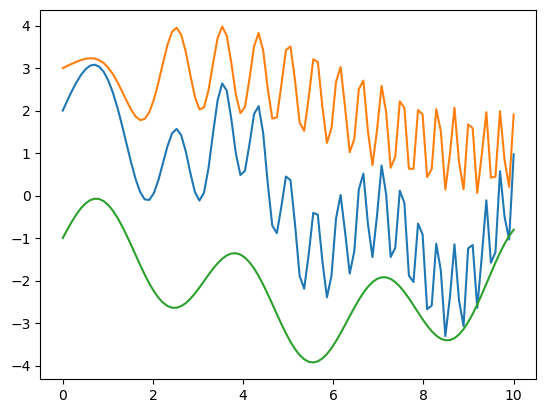

In [3]:
a, b = 1, 0.1
x = np.linspace(0,10,100)
y = f(x,a,b)

plt.plot(x,y)
plt.plot(x,component1(x)+2, label='c1')
plt.plot(x,component2(x)-2, label='c2')

We're going to evaluate these in a dense grid in a and b.

In [4]:
aa, bb = np.meshgrid(np.linspace(-5,5,20), np.linspace(-2,5,21))

function_grid = np.array([f(x,aa_,bb_) for aa_,bb_ in zip(aa.ravel(), bb.ravel())])
# function_grid -= function_grid.mean(1, keepdims=True)

We do SVD to try and find some basis functions that span this space of curves.

In [7]:
u, s, vt = np.linalg.svd(function_grid)

print(u.shape, s.shape, vt.shape, function_grid.shape)

(420, 420) (100,) (100, 100) (420, 100)


Plot the singular values: we ssee, correctly, that there are only two nonzero singular values, because the data only vary along two dimensions.

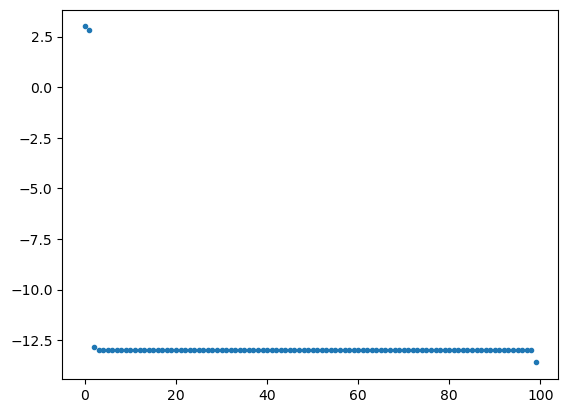

In [277]:
plt.plot(np.log10(s),'.')

What do these basis functions look like?

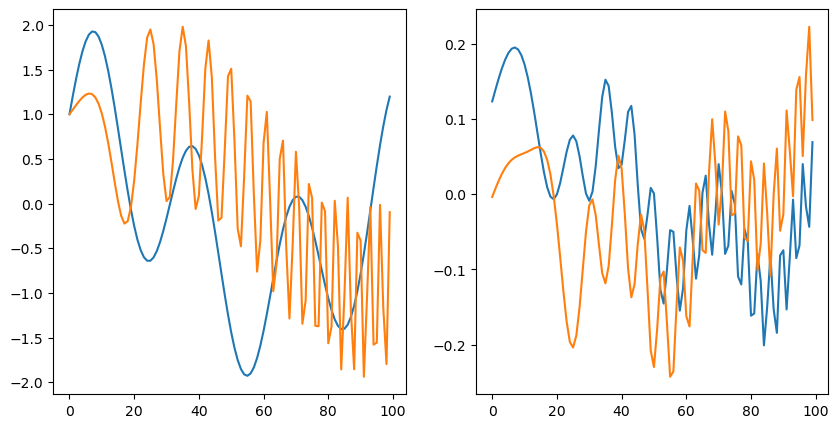

In [309]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.plot(component2(x))
ax1.plot(component1(x))

ax2.plot(vt[0])
ax2.plot(vt[1])

We see that the true basis functions are kinda mixed together. This will in general be the case if they are not properly orthonormal; we're not learning true physics processes, just proxies for them.

Let's project our data grid onto these basis functions and see how smoothly they vary with a and b:

(420, 100)


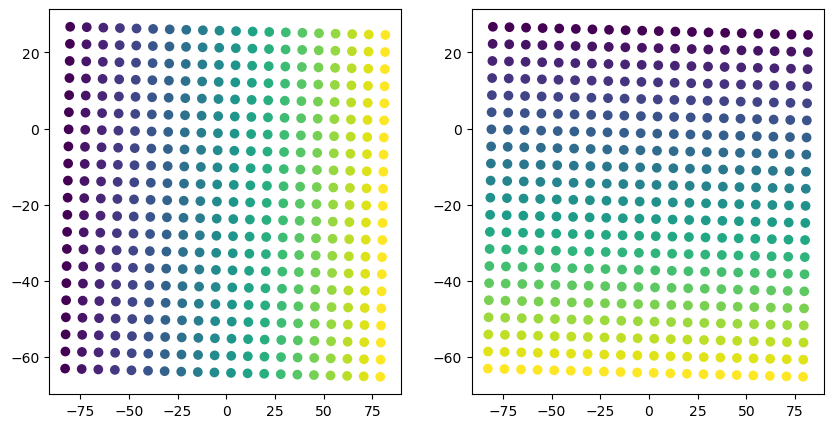

In [8]:
# now to associate these with the parameters a and b
projections = function_grid @ vt.T

print(projections.shape)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.scatter(projections[:,0], projections[:,1], c=aa.ravel())
ax2.scatter(projections[:,0], projections[:,1], c=bb.ravel())

Nice, the first two components fall out neatly as a regular grid with a smooth gradient in a and in b. Let's find the coefficients for those linear trends in a and b:

In [311]:
# linear least squares
X = np.vstack([aa.ravel(), bb.ravel()]).T
y = projections[:,:2]

coeffs = np.linalg.lstsq(X,y, rcond=None)[0]
coeffs

array([[ 16.17564483,  -0.21513643],
       [ -0.37049881, -12.83234193]])

These aren't the coefficients we put in! They might be only if we have orthonormal basis functions. 

But they do give us exact reconstructions of the data:

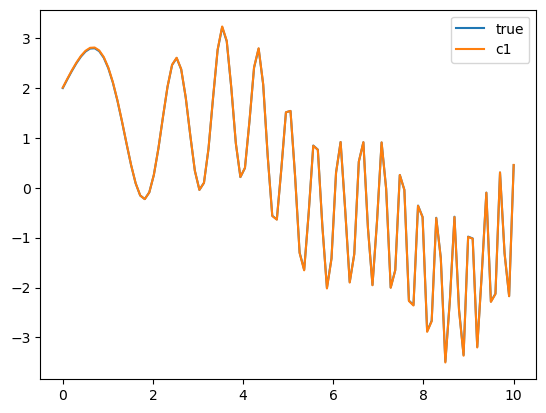

In [312]:
a, b = 1, 0.5
x = np.linspace(0,10,100)
y = f(x,a,b)

recon = (coeffs[0,0] * a + coeffs[0,1] * b) * vt[0] + (coeffs[0,1] * a + coeffs[1,1]*b) * vt[1]

plt.plot(x,y, label='true')

plt.plot(x,recon, label='c1')

plt.legend()